# Stage 3: Tree Models + Hyperparameter Optimization

**Objective**: Build strong tree-based baselines (RF, XGBoost, LightGBM, CatBoost), optimize with Optuna, and compare ensemble strategies.

**Sub-stages**:
- 3a: Default-param comparison (RF, XGB, LGB, CB)
- 3b: Optuna hyperparameter optimization (50 trials per model)
- 3c: Stacking & Blending ensemble
- 3d: Class imbalance strategies (none, class_weight, scale_pos_weight, SMOTE)

**Output**: `results/models/` — best model per type, `results/analysis_reports/` — comparison charts.

In [13]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('muted')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'results' / 'analysis_reports'
MODEL_DIR = PROJECT_ROOT / 'results' / 'models'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Model dir:    {MODEL_DIR}')
print(f'Report dir:   {REPORT_DIR}')

Project root: /Users/siwei_wang/Documents/project_proposals_financial
Data dir:     /Users/siwei_wang/Documents/project_proposals_financial/data/processed
Model dir:    /Users/siwei_wang/Documents/project_proposals_financial/results/models
Report dir:   /Users/siwei_wang/Documents/project_proposals_financial/results/analysis_reports


In [14]:
# Load processed data
train = pd.read_parquet(DATA_DIR / 'train.parquet')
val = pd.read_parquet(DATA_DIR / 'val.parquet')
test = pd.read_parquet(DATA_DIR / 'test.parquet')

print(f'Train: {train.shape[0]:,} rows, {train.shape[1]} cols, bad_rate={train["is_bad"].mean():.2%}')
print(f'Val:   {val.shape[0]:,} rows, {val.shape[1]} cols, bad_rate={val["is_bad"].mean():.2%}')
print(f'Test:  {test.shape[0]:,} rows, {test.shape[1]} cols, bad_rate={test["is_bad"].mean():.2%}')

Train: 451,060 rows, 68 cols, bad_rate=16.96%
Val:   375,546 rows, 68 cols, bad_rate=20.19%
Test:  293,105 rows, 68 cols, bad_rate=23.29%


In [15]:
# Prepare feature matrices
# Drop grade/sub_grade (leaked through int_rate), addr_state/zip_code (fairness proxies)
from src.models.tree_models import prepare_features

X_train, y_train, num_cols, cat_cols = prepare_features(train)
X_val, y_val, _, _ = prepare_features(val)
X_test, y_test, _, _ = prepare_features(test)

print(f'X_train: {X_train.shape[1]} features ({len(num_cols)} numeric, {len(cat_cols)} categorical)')
print(f'y_train: {y_train.shape[0]:,} samples, bad_rate={y_train.mean():.2%}')
print(f'cat_cols: {cat_cols}')

X_train: 62 features (55 numeric, 7 categorical)
y_train: 451,060 samples, bad_rate=16.96%
cat_cols: ['term', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'earliest_cr_line', 'initial_list_status']


---
# Part 1: Baseline Tree Models (Default Parameters)
---

In [26]:
from src.models.tree_models import make_model, train_model, predict_proba, evaluate_model, results_to_dataframe, save_model
from sklearn.metrics import roc_auc_score

model_names = ['rf', 'xgb', 'lgb', 'cb']
model_labels = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']

baseline_results = []
baseline_models = {}

for name, label in zip(model_names, model_labels):
    print(f'\n{"="*60}')
    print(f'  Training: {label}')
    print(f'{"="*60}')
    
    t0 = time.time()
    model = make_model(name)
    train_model(model, X_train, y_train, X_val, y_val, cat_features=cat_cols)
    elapsed = time.time() - t0
    
    result = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test,
                           label=label, fit_time=elapsed)
    baseline_results.append(result)
    baseline_models[name] = model
    
    # Save model weights
    save_model(model, MODEL_DIR / f'{name}_baseline_stage3.pkl')
    
    print(f'  Train AUC={result["train_auc"]:.4f}  |  Val AUC={result["val_auc"]:.4f}  |  Test AUC={result["test_auc"]:.4f}')
    print(f'  Train KS ={result["train_ks"]:.4f}  |  Val KS ={result["val_ks"]:.4f}  |  Test KS ={result["test_ks"]:.4f}')
    print(f'  Fit time: {elapsed:.1f}s')

# Save baseline comparison CSV
df_baseline = results_to_dataframe(baseline_results)
df_baseline.to_csv(REPORT_DIR / 'baseline_model_results.csv', index=False)

print(f'\n{"="*60}')
print('  BASELINE COMPARISON')
print(f'{"="*60}')
print(df_baseline[['model','test_auc','test_ks','test_gini','test_pr_auc','fit_time_sec']].to_string(index=False))



  Training: Random Forest
  Train AUC=0.7317  |  Val AUC=0.7359  |  Test AUC=0.7134
  Train KS =0.3387  |  Val KS =0.3446  |  Test KS =0.3111
  Fit time: 57.8s

  Training: XGBoost
  Train AUC=0.7491  |  Val AUC=0.7411  |  Test AUC=0.7191
  Train KS =0.3666  |  Val KS =0.3510  |  Test KS =0.3163
  Fit time: 110.9s

  Training: LightGBM
[50]	training's auc: 0.718446	valid_1's auc: 0.736617
[100]	training's auc: 0.729908	valid_1's auc: 0.739459
[150]	training's auc: 0.738687	valid_1's auc: 0.740528
[200]	training's auc: 0.746443	valid_1's auc: 0.74085
[250]	training's auc: 0.75315	valid_1's auc: 0.740858
  Train AUC=0.7515  |  Val AUC=0.7409  |  Test AUC=0.7188
  Train KS =0.3702  |  Val KS =0.3511  |  Test KS =0.3180
  Fit time: 26.2s

  Training: CatBoost
  Train AUC=0.7260  |  Val AUC=0.7418  |  Test AUC=0.7194
  Train KS =0.3288  |  Val KS =0.3520  |  Test KS =0.3189
  Fit time: 258.6s

  BASELINE COMPARISON
        model  test_auc  test_ks  test_gini  test_pr_auc  fit_time_sec
    

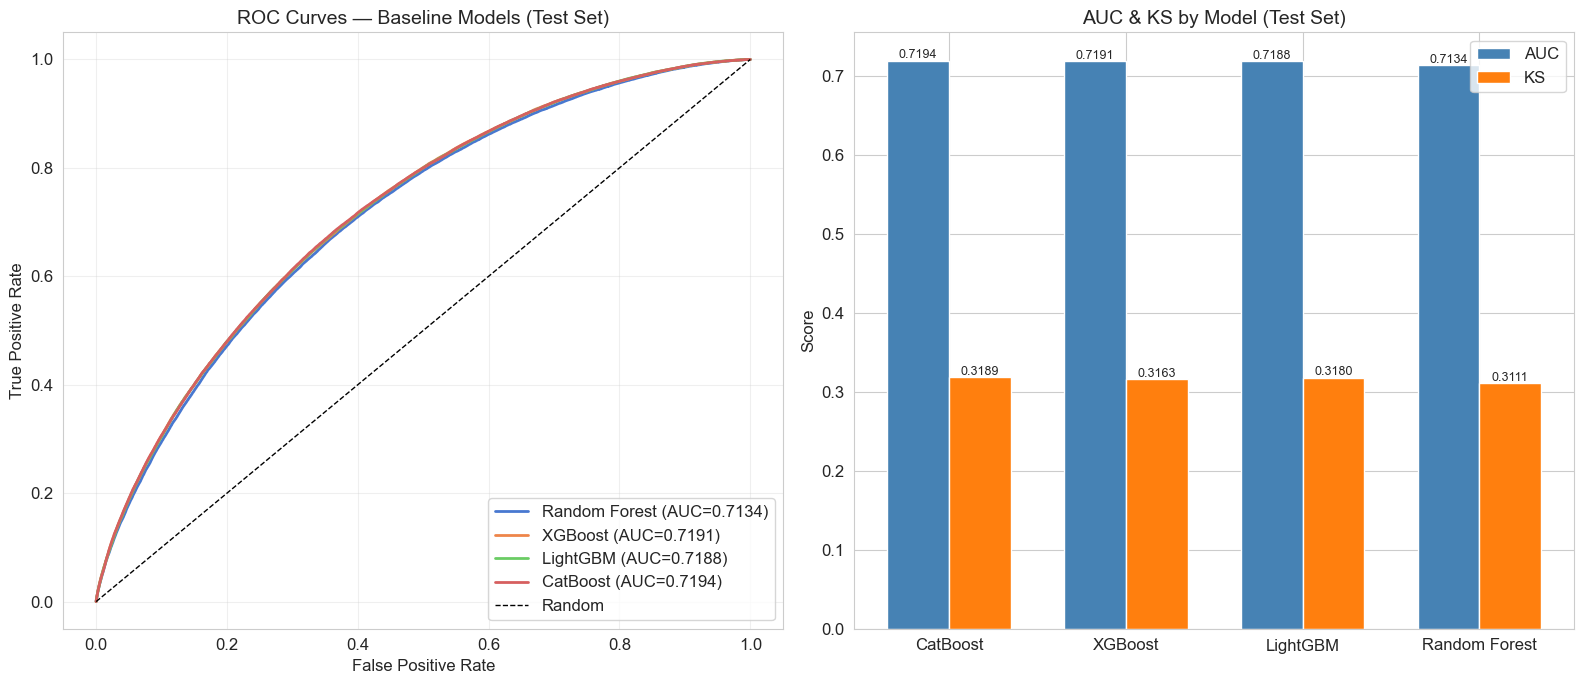

In [17]:
# ROC curves for all baseline models
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Test ROC
ax = axes[0]
for name, label in zip(model_names, model_labels):
    model = baseline_models[name]
    yp = predict_proba(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Baseline Models (Test Set)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Bar chart comparison
ax = axes[1]
df_baseline = results_to_dataframe(baseline_results)
x = range(len(df_baseline))
bars_auc = ax.bar(x, df_baseline['test_auc'], width=0.35, label='AUC', color='steelblue')
bars_ks = ax.bar([i+0.35 for i in x], df_baseline['test_ks'], width=0.35, label='KS', color='#ff7f0e')
ax.set_xticks([i+0.175 for i in x])
ax.set_xticklabels(df_baseline['model'])
ax.set_ylabel('Score')
ax.set_title('AUC & KS by Model (Test Set)')
ax.legend()
for bar, val in zip(bars_auc, df_baseline['test_auc']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{val:.4f}', ha='center', fontsize=9)
for bar, val in zip(bars_ks, df_baseline['test_ks']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORT_DIR / '15_baseline_models.png', dpi=150, bbox_inches='tight')
plt.show()

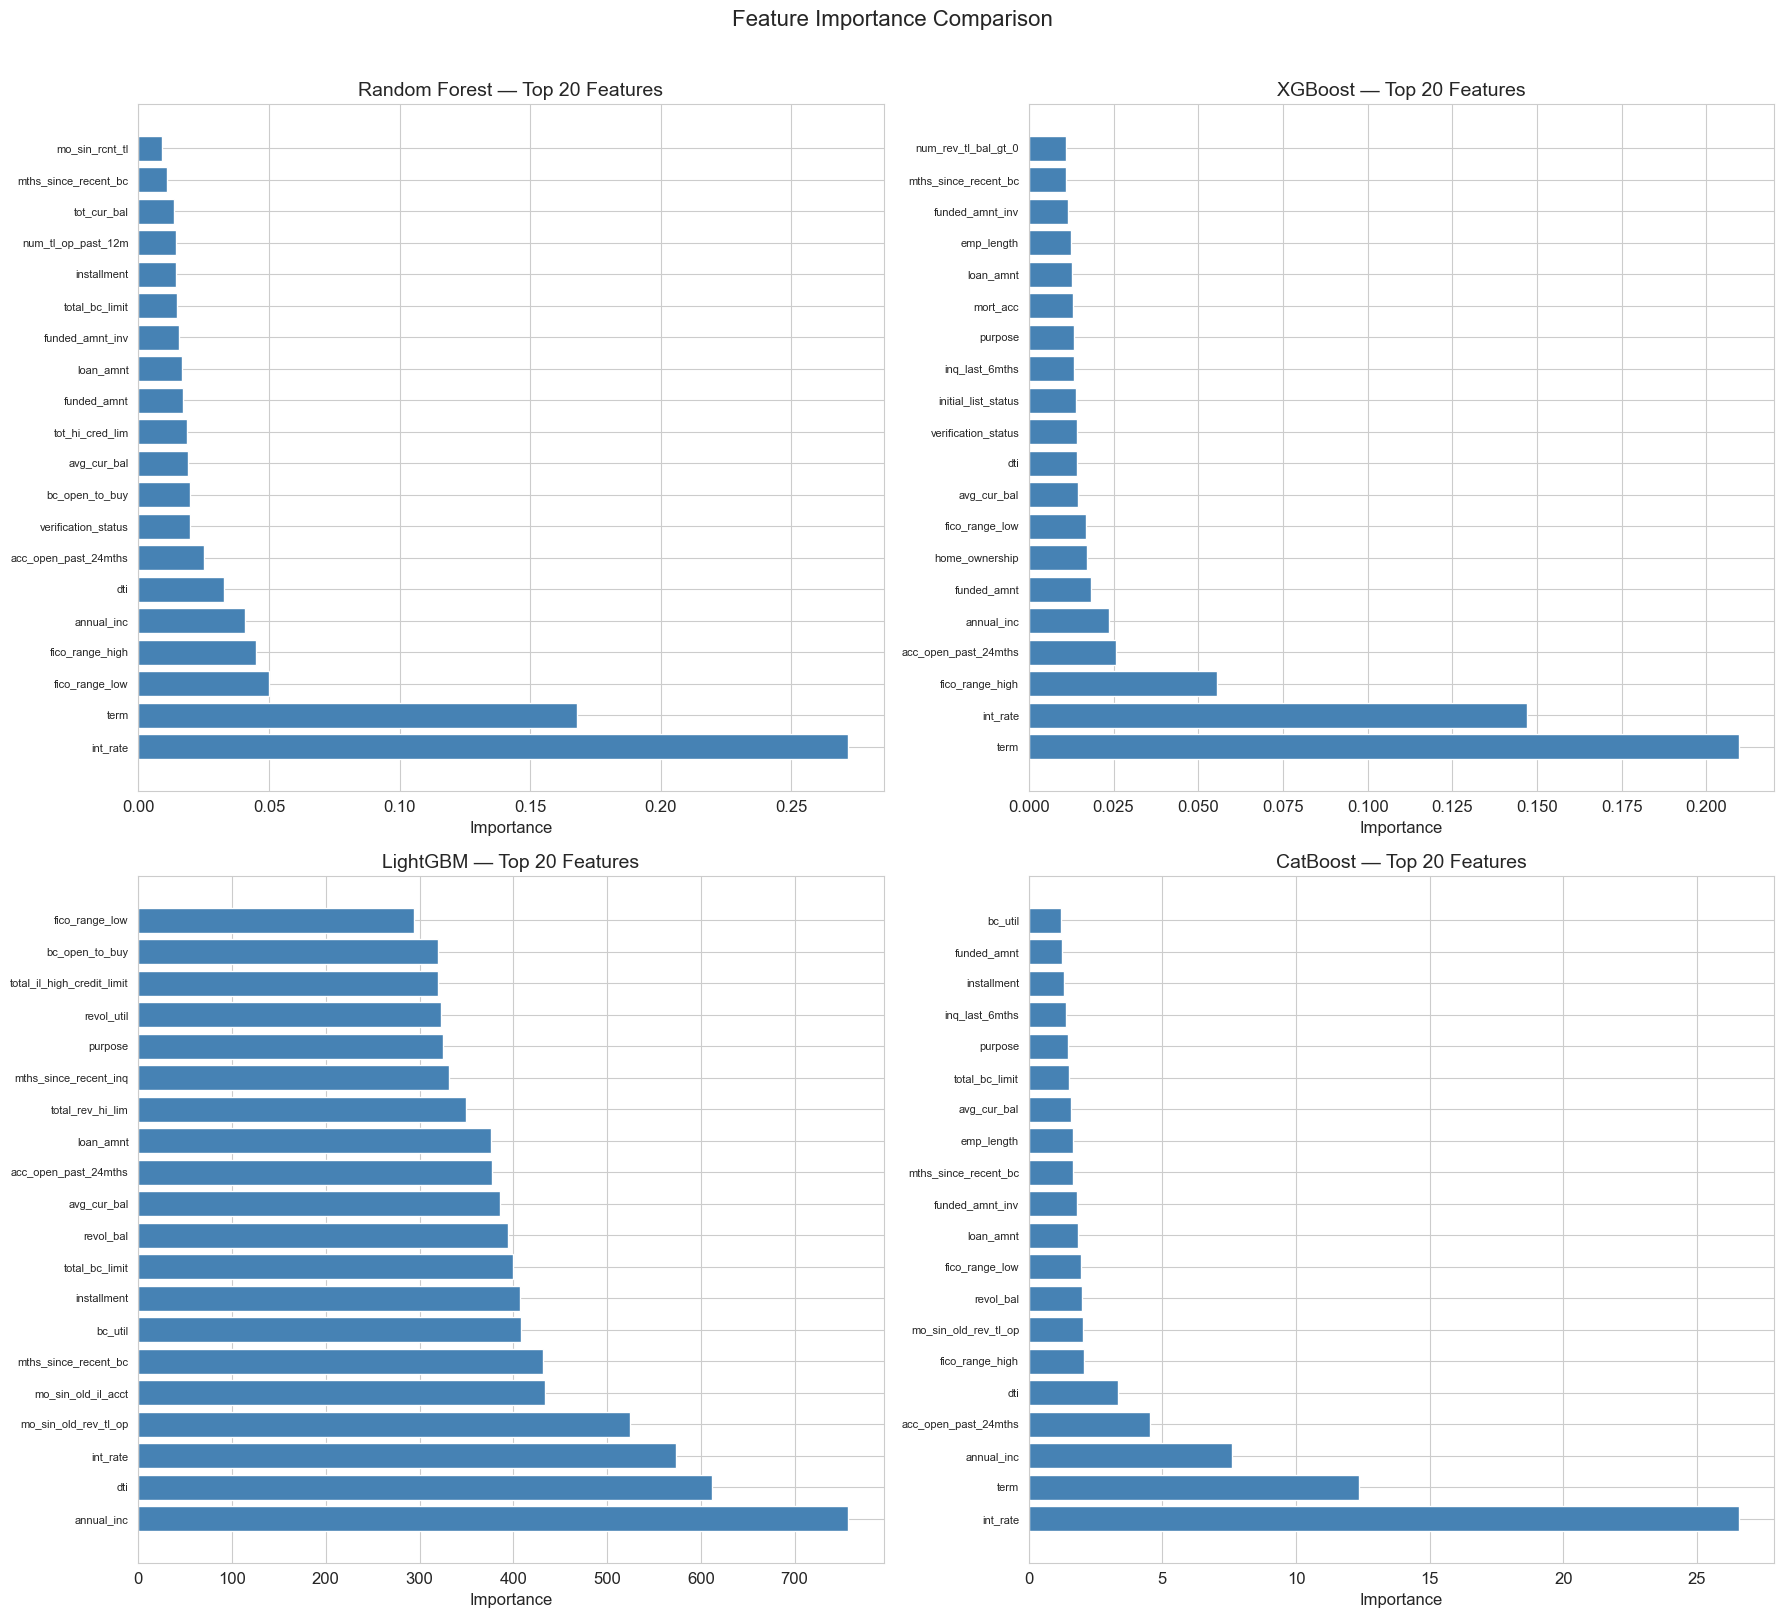

In [18]:
# Feature importance comparison (top 20 per model)
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for i, (name, label) in enumerate(zip(model_names, model_labels)):
    model = baseline_models[name]
    ax = axes[i]
    
    # Get feature importance
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        feat_names = X_train.columns
    elif hasattr(model, 'get_score'):
        imp_dict = model.get_score(importance_type='gain')
        feat_names = list(imp_dict.keys())
        imp = np.array(list(imp_dict.values()))
    else:
        ax.set_title(f'{label} — No feature_importances_')
        continue
    
    idx = np.argsort(imp)[-20:]
    top_feats = [feat_names[j] for j in idx]
    top_imp = imp[idx]
    
    ax.barh(range(len(top_feats)), top_imp, color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Importance')
    ax.set_title(f'{label} — Top 20 Features')

plt.suptitle('Feature Importance Comparison', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(REPORT_DIR / '16_baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 2: Hyperparameter Optimization with Optuna
---

In [19]:
from src.models.tree_models import optimize_model, make_model, train_model, evaluate_model, get_imbalance_params, save_model, load_model

# Optimize the top-2 performers from baseline (XGB and LGB typically)
opt_models = ['xgb', 'lgb']
opt_labels = ['XGBoost (Optuna)', 'LightGBM (Optuna)']
opt_results = []
opt_model_objects = {}
opt_best_params = {}

N_TRIALS = 50

for name, label in zip(opt_models, opt_labels):
    print(f'\n{"="*60}')
    
    model_path = MODEL_DIR / f'{name}_optuna_stage3.pkl'
    trials_csv = REPORT_DIR / f'optuna_trials_{name}.csv'
    
    if model_path.exists():
        # Already saved -- load directly, no retraining needed
        print(f'  {label}: Loading from {model_path.name}')
        best_model = load_model(model_path)
        if trials_csv.exists():
            trials_df = pd.read_csv(trials_csv)
        best_params = {}
        elapsed = 0.0
    elif trials_csv.exists():
        # CSV exists but model not saved -- restore params and retrain
        trials_df = pd.read_csv(trials_csv)
        best_idx = trials_df['value'].idxmax()
        best_val_auc = trials_df['value'].max()
        
        param_cols = [c for c in trials_df.columns if c.startswith('params_')]
        best_params = {}
        for col in param_cols:
            key = col.replace('params_', '')
            val = trials_df.loc[best_idx, col]
            if isinstance(val, np.integer):
                val = int(val)
            elif isinstance(val, np.floating):
                val = float(val)
            best_params[key] = val
        
        print(f'  {label}: Restoring from {trials_csv.name} (best val AUC={best_val_auc:.4f})')
        print(f'  Training final model with best params...')
        print(f'  Best params: {json.dumps(best_params, indent=2)}')
        
        t0 = time.time()
        extra = get_imbalance_params(name, 'scale_pos_weight', y_train)
        extra.update(best_params)
        best_model = make_model(name, extra)
        train_model(best_model, X_train, y_train, X_val, y_val, cat_features=cat_cols)
        elapsed = time.time() - t0
        
        # Save so next time it's instant
        save_model(best_model, model_path)
        print(f'  Model saved to {model_path.name}')
    else:
        print(f'  Optuna Optimization: {label} ({N_TRIALS} trials)')
        print(f'{"="*60}')
        
        t0 = time.time()
        best_model, best_params, trials_df = optimize_model(
            model_name=name,
            X_train=X_train, y_train=y_train,
            X_val=X_val, y_val=y_val,
            n_trials=N_TRIALS,
            cat_features=cat_cols,
            save_dir=MODEL_DIR,
        )
        elapsed = time.time() - t0
        trials_df.to_csv(trials_csv, index=False)
        print(f'  Best params: {json.dumps(best_params, indent=2)}')
        print(f'  Search + train time: {elapsed/60:.1f} min')
    
    result = evaluate_model(best_model, X_train, y_train, X_val, y_val, X_test, y_test,
                           label=label, fit_time=elapsed)
    opt_results.append(result)
    opt_model_objects[name] = best_model
    opt_best_params[name] = best_params
    
    print(f'  Test AUC={result["test_auc"]:.4f}  |  Test KS={result["test_ks"]:.4f}')



  XGBoost (Optuna): Loading from xgb_optuna_stage3.pkl
  Test AUC=0.7202  |  Test KS=0.3178

  LightGBM (Optuna): Loading from lgb_optuna_stage3.pkl
  Test AUC=0.7184  |  Test KS=0.3176


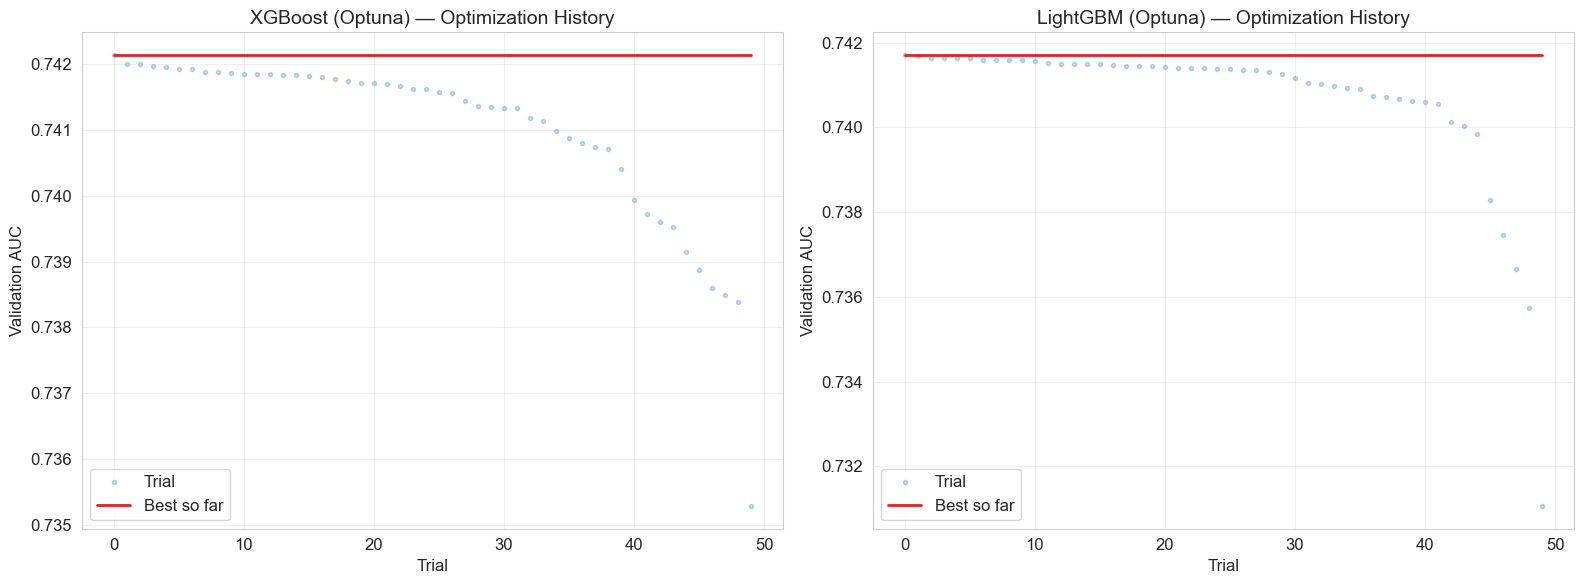

In [20]:
# Optuna optimization history plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, label) in enumerate(zip(opt_models, opt_labels)):
    trials_df = pd.read_csv(REPORT_DIR / f'optuna_trials_{name}.csv')
    ax = axes[i]
    
    # Best value so far
    best_so_far = np.maximum.accumulate(trials_df['value'].values)
    ax.plot(trials_df.index, trials_df['value'], 'o', alpha=0.3, markersize=3, color='steelblue', label='Trial')
    ax.plot(trials_df.index, best_so_far, '-', color='#d62728', lw=2, label='Best so far')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Validation AUC')
    ax.set_title(f'{label} — Optimization History')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_DIR / '17_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

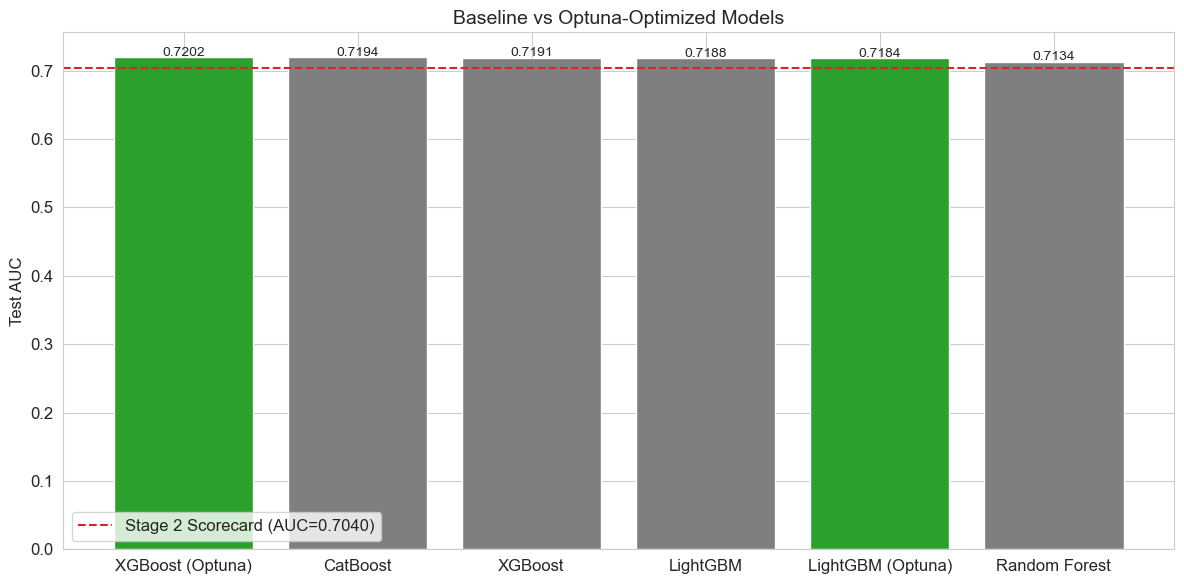

In [21]:
# Compare baseline vs optimized
all_results_sofar = baseline_results + opt_results
df_sofar = results_to_dataframe(all_results_sofar)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_sofar))
colors = ['#7f7f7f' if 'Optuna' not in m else '#2ca02c' for m in df_sofar['model']]
bars = ax.bar(x, df_sofar['test_auc'], color=colors, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(df_sofar['model'])
ax.set_ylabel('Test AUC')
ax.set_title('Baseline vs Optuna-Optimized Models')
for bar, val in zip(bars, df_sofar['test_auc']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.4f}', ha='center', fontsize=10)
ax.axhline(y=0.7040, color='#d62728', linestyle='--', lw=1.5, label='Stage 2 Scorecard (AUC=0.7040)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / '18_baseline_vs_optuna.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3: Ensemble (Stacking & Blending)
---

In [22]:
from src.models.tree_models import StackingEnsemble, blend_predictions
from sklearn.metrics import roc_auc_score

# Use optimized XGB + LGB + baseline CB as base models
base_xgb = opt_model_objects.get('xgb', baseline_models['xgb'])
base_lgb = opt_model_objects.get('lgb', baseline_models['lgb'])
base_cb = baseline_models['cb']

print('Building stacking ensemble...')
t0 = time.time()

stacking = StackingEnsemble(
    base_models=[base_xgb, base_lgb, base_cb],
    cv_folds=5,
)
stacking.fit(X_train, y_train, X_val, y_val, cat_features=cat_cols)

elapsed = time.time() - t0

# Evaluate
from src.evaluation.metrics import auc_score, ks_score, gini_score, pr_auc

for name, X, y in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    yp = stacking.predict_proba(X)
    print(f'{name}: AUC={auc_score(y, yp):.4f}  KS={ks_score(y, yp):.4f}  Gini={gini_score(y, yp):.4f}  PR-AUC={pr_auc(y, yp):.4f}')
print(f'\nFit time: {elapsed:.1f}s')

# Blending (equal weights)
blend_preds_test = blend_predictions({
    'xgb': predict_proba(base_xgb, X_test),
    'lgb': predict_proba(base_lgb, X_test),
    'cb': predict_proba(base_cb, X_test),
})
print(f'\nBlending (equal weights) Test AUC={auc_score(y_test, blend_preds_test):.4f}  KS={ks_score(y_test, blend_preds_test):.4f}')

Building stacking ensemble...
Train: AUC=0.7439  KS=0.3545  Gini=0.4878  PR-AUC=0.3818
Val: AUC=0.7423  KS=0.3532  Gini=0.4847  PR-AUC=0.4245
Test: AUC=0.7202  KS=0.3191  Gini=0.4404  PR-AUC=0.4308

Fit time: 10.3s

Blending (equal weights) Test AUC=0.7204  KS=0.3195


In [23]:
# Stacking ensemble result
yp_test_stack = stacking.predict_proba(X_test)
stack_result = {
    'model': 'Stacking (XGB+LGB+CB)',
    'test_auc': auc_score(y_test, yp_test_stack),
    'test_ks': ks_score(y_test, yp_test_stack),
    'test_gini': gini_score(y_test, yp_test_stack),
    'test_pr_auc': pr_auc(y_test, yp_test_stack),
    'fit_time_sec': round(elapsed, 1),
}

blend_result = {
    'model': 'Blending (XGB+LGB+CB)',
    'test_auc': auc_score(y_test, blend_preds_test),
    'test_ks': ks_score(y_test, blend_preds_test),
    'test_gini': gini_score(y_test, blend_preds_test),
    'test_pr_auc': pr_auc(y_test, blend_preds_test),
    'fit_time_sec': 0.1,
}

ensemble_results = [stack_result, blend_result]
print(results_to_dataframe(ensemble_results)[['model','test_auc','test_ks','test_gini','test_pr_auc']].to_string(index=False))

                model  test_auc  test_ks  test_gini  test_pr_auc
Blending (XGB+LGB+CB)  0.720351 0.319523   0.440701     0.430853
Stacking (XGB+LGB+CB)  0.720210 0.319150   0.440420     0.430786


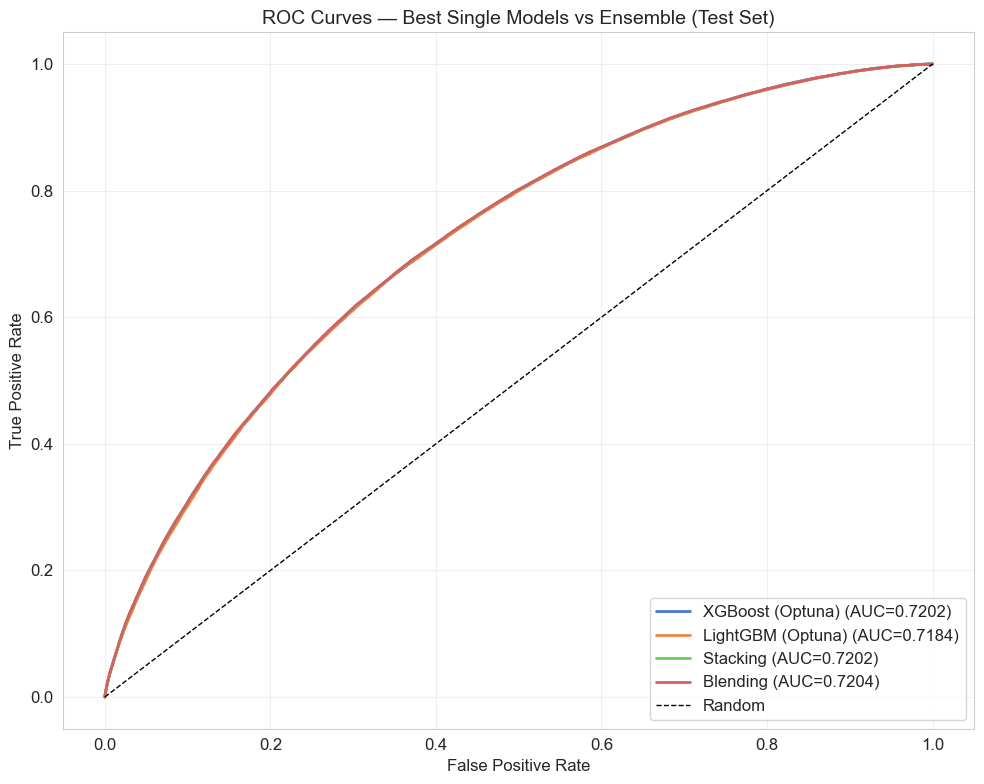

In [24]:
# ROC comparison: best single model vs ensemble
fig, ax = plt.subplots(figsize=(10, 8))

best_single = opt_model_objects.get('lgb', baseline_models['lgb'])
for label, yp in [
    ('XGBoost (Optuna)', predict_proba(opt_model_objects.get('xgb', baseline_models['xgb']), X_test)),
    ('LightGBM (Optuna)', predict_proba(best_single, X_test)),
    ('Stacking', yp_test_stack),
    ('Blending', blend_preds_test),
]:
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Best Single Models vs Ensemble (Test Set)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_DIR / '19_ensemble_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 4: Class Imbalance Strategies
---

In [27]:
from src.models.tree_models import get_imbalance_params
from imblearn.over_sampling import SMOTE

strategies = ['none', 'balanced', 'scale_pos_weight', 'smote']
strategy_labels = ['None', 'Class Weight', 'Scale Pos Weight', 'SMOTE']

imb_results = []

for strat, s_label in zip(strategies, strategy_labels):
    print(f'\n--- {s_label} ---')
    t0 = time.time()
    
    if strat == 'smote':
        # Fill NaN in numeric columns before SMOTE
        X_tr_filled = X_train.copy()
        for c in X_tr_filled.columns:
            if X_tr_filled[c].isna().any():
                X_tr_filled[c] = X_tr_filled[c].fillna(X_tr_filled[c].median())
        
        smote = SMOTE(random_state=42, sampling_strategy=0.5)
        X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr_filled.values, y_train.values)
        X_tr_smote = pd.DataFrame(X_tr_resampled, columns=X_train.columns)
        y_tr_smote = pd.Series(y_tr_resampled, name='is_bad')
        print(f'  SMOTE: {X_train.shape[0]:,} -> {X_tr_smote.shape[0]:,} samples (bad_rate={y_tr_smote.mean():.2%})')
    else:
        X_tr_smote = X_train
        y_tr_smote = y_train
    
    # Use XGBoost as the test model
    extra = get_imbalance_params('xgb', strat, y_train)
    if strat == 'none' and 'scale_pos_weight' not in extra:
        extra = {}
    
    model = make_model('xgb', extra)
    train_model(model, X_tr_smote, y_tr_smote, X_val, y_val, cat_features=cat_cols)
    elapsed = time.time() - t0
    
    result = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test,
                           label=f'XGB ({s_label})', fit_time=elapsed)
    imb_results.append(result)
    print(f'  Test AUC={result["test_auc"]:.4f}  Test KS={result["test_ks"]:.4f}  Time={elapsed:.1f}s')



--- None ---
  Test AUC=0.7191  Test KS=0.3163  Time=73.4s

--- Class Weight ---
  Test AUC=0.7190  Test KS=0.3174  Time=71.9s

--- Scale Pos Weight ---
  Test AUC=0.7190  Test KS=0.3174  Time=75.3s

--- SMOTE ---
  SMOTE: 451,060 -> 561,840 samples (bad_rate=33.33%)
  Test AUC=0.6929  Test KS=0.2846  Time=29.1s


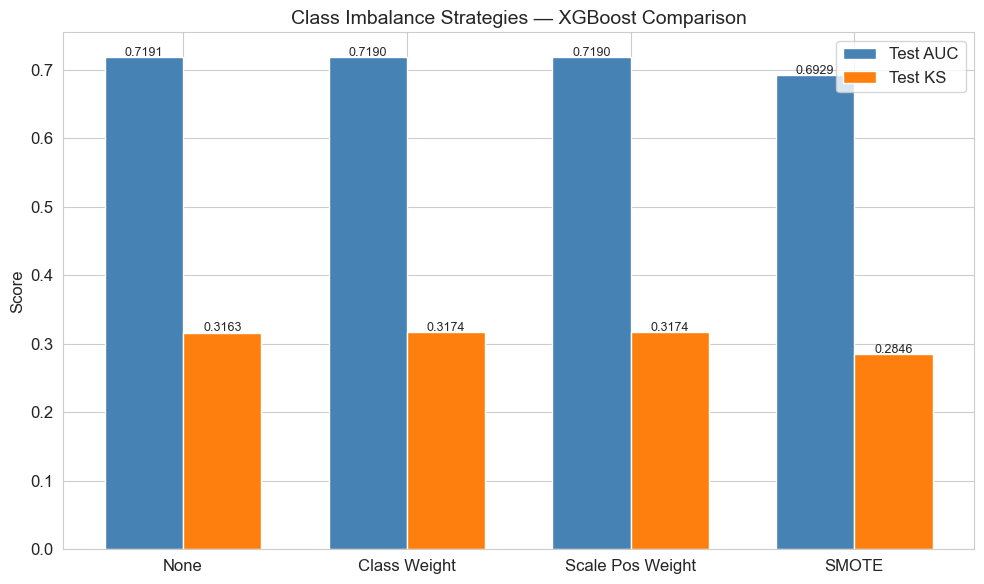

                 model  test_auc  test_ks  test_pr_auc  fit_time_sec
            XGB (None)    0.7191   0.3163       0.4294          73.4
    XGB (Class Weight)    0.7190   0.3174       0.4292          71.9
XGB (Scale Pos Weight)    0.7190   0.3174       0.4292          75.3
           XGB (SMOTE)    0.6929   0.2846       0.3839          29.1


In [28]:
# Imbalance strategy comparison
df_imb = results_to_dataframe(imb_results)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(df_imb))
bars_auc = ax.bar(x, df_imb['test_auc'], width=0.35, label='Test AUC', color='steelblue')
bars_ks = ax.bar([i+0.35 for i in x], df_imb['test_ks'], width=0.35, label='Test KS', color='#ff7f0e')
ax.set_xticks([i+0.175 for i in x])
ax.set_xticklabels([m.replace('XGB (', '').replace(')', '') for m in df_imb['model']])
ax.set_ylabel('Score')
ax.set_title('Class Imbalance Strategies — XGBoost Comparison')
ax.legend()
for bar, val in zip(bars_auc, df_imb['test_auc']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.4f}', ha='center', fontsize=9)
for bar, val in zip(bars_ks, df_imb['test_ks']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORT_DIR / '20_imbalance_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_imb[['model','test_auc','test_ks','test_pr_auc','fit_time_sec']].to_string(index=False))

---
# Part 5: Complete Model Comparison
---

In [29]:
# Compile all results
all_results = baseline_results + opt_results + ensemble_results
df_all = results_to_dataframe(all_results)

# Add Stage 2 reference
stage2_row = {
    'model': 'Stage 2 — WOE Scorecard',
    'test_auc': 0.7040,
    'test_ks': 0.2946,
    'test_gini': 0.4079,
    'test_pr_auc': 0.4110,
    'fit_time_sec': 5.0,
}
df_all = pd.concat([df_all, pd.DataFrame([stage2_row])], ignore_index=True)
df_all = df_all.sort_values('test_auc', ascending=False).reset_index(drop=True)

print('=' * 90)
print(f'{"COMPLETE MODEL COMPARISON — Stage 2 + Stage 3":^90}')
print('=' * 90)
comparison_cols = ['model', 'test_auc', 'test_ks', 'test_gini', 'test_pr_auc', 'fit_time_sec']
display_cols = [c for c in comparison_cols if c in df_all.columns]
print(df_all[display_cols].to_string(index=False))
df_all[display_cols].to_csv(REPORT_DIR / 'model_comparison.csv', index=False)

                      COMPLETE MODEL COMPARISON — Stage 2 + Stage 3                       
                  model  test_auc  test_ks  test_gini  test_pr_auc  fit_time_sec
  Blending (XGB+LGB+CB)  0.720351 0.319523   0.440701     0.430853           0.1
  Stacking (XGB+LGB+CB)  0.720210 0.319150   0.440420     0.430786          10.3
       XGBoost (Optuna)  0.720200 0.317800   0.440300     0.430600           0.0
               CatBoost  0.719400 0.318900   0.438700     0.429200         258.6
                XGBoost  0.719100 0.316300   0.438200     0.429400         110.9
               LightGBM  0.718800 0.318000   0.437500     0.428100          26.2
      LightGBM (Optuna)  0.718400 0.317600   0.436900     0.427600           0.0
          Random Forest  0.713400 0.311100   0.426900     0.421200          57.8
Stage 2 — WOE Scorecard  0.704000 0.294600   0.407900     0.411000           5.0


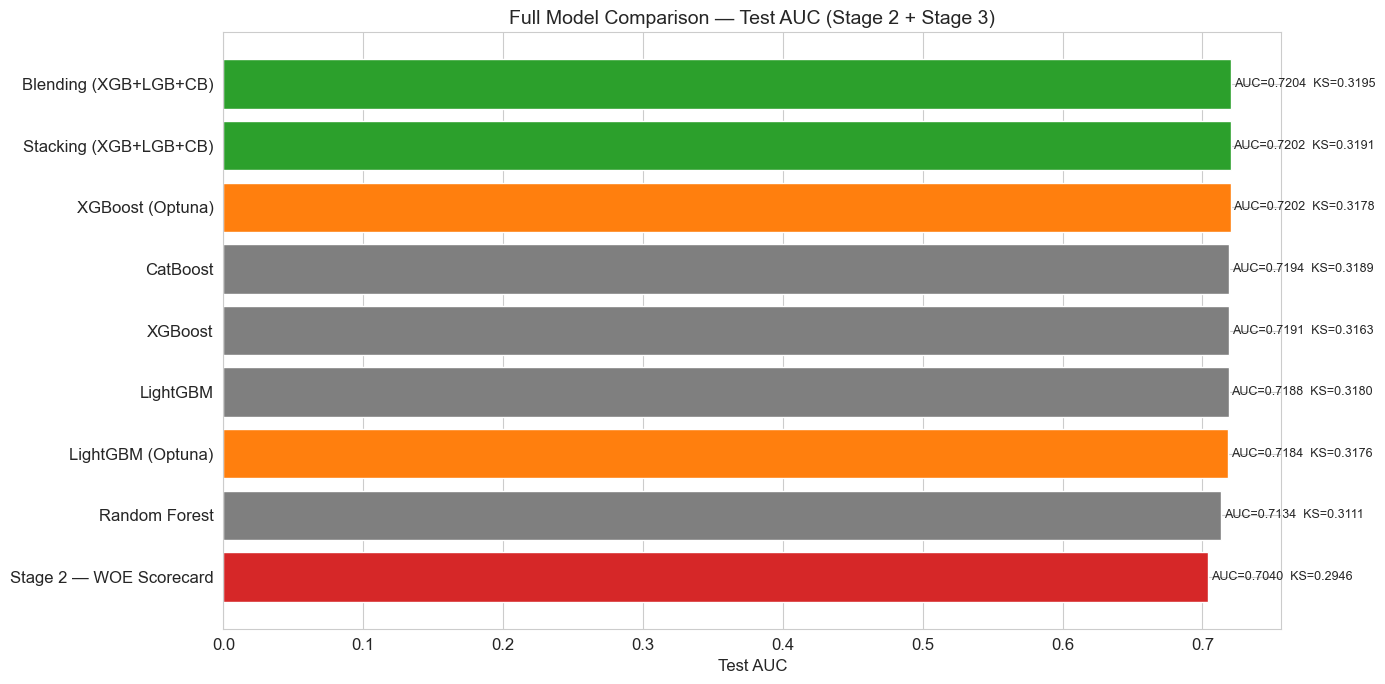

In [30]:
# Final comparison bar chart
fig, ax = plt.subplots(figsize=(14, 7))

df_plot = df_all.sort_values('test_auc', ascending=True)
x = range(len(df_plot))
colors = ['#2ca02c' if 'Stacking' in m or 'Blending' in m
          else '#ff7f0e' if 'Optuna' in m
          else '#d62728' if 'Scorecard' in m
          else '#7f7f7f' for m in df_plot['model']]

bars = ax.barh(x, df_plot['test_auc'], color=colors, edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(df_plot['model'])
ax.set_xlabel('Test AUC')
ax.set_title('Full Model Comparison — Test AUC (Stage 2 + Stage 3)')

for bar, val, ks in zip(bars, df_plot['test_auc'], df_plot['test_ks']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'AUC={val:.4f}  KS={ks:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORT_DIR / '21_final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best model: Blending (XGB+LGB+CB)


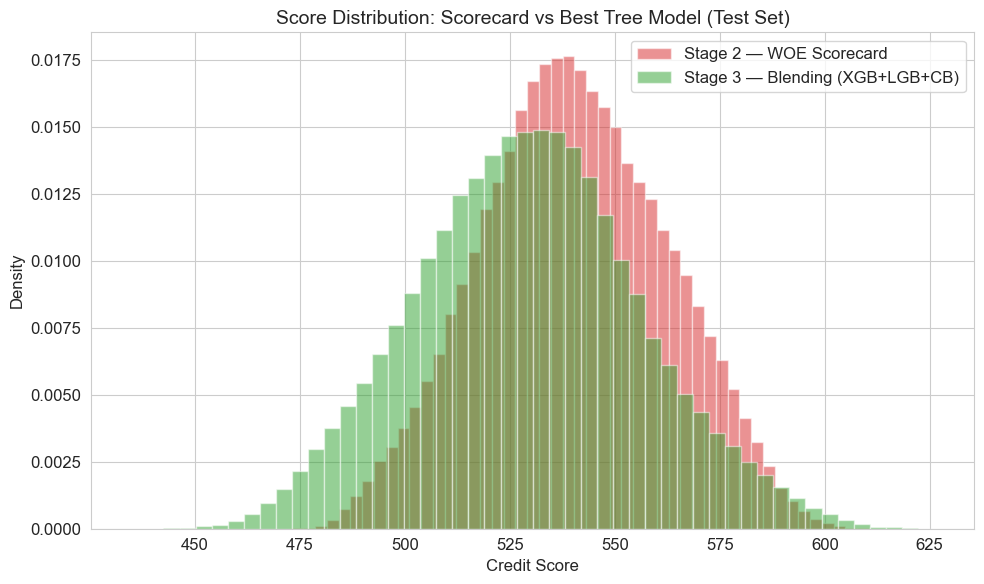

In [31]:
# Score distribution comparison (best tree model vs Stage 2 scorecard)
from src.models.scorecard import Scorecard

# Load Stage 2 scorecard
sc = Scorecard.load(MODEL_DIR / 'scorecard_stage2.pkl')
scorecard_scores = sc.predict_score(test)

# Get best tree model scores
best_model_name = df_all[~df_all['model'].str.contains('Stage 2')].iloc[0]['model']
print(f'Best model: {best_model_name}')

if 'xgb' in best_model_name.lower():
    tree_preds = predict_proba(opt_model_objects.get('xgb', baseline_models['xgb']), X_test)
elif 'lgb' in best_model_name.lower():
    tree_preds = predict_proba(opt_model_objects.get('lgb', baseline_models['lgb']), X_test)
elif 'stacking' in best_model_name.lower():
    tree_preds = stacking.predict_proba(X_test)
else:
    tree_preds = predict_proba(baseline_models['xgb'], X_test)

# Convert tree probs to score-like scale for comparison
factor = 20 / np.log(2)
offset = 600 - factor * np.log(50)
tree_probs_clipped = np.clip(tree_preds, 1e-10, 1 - 1e-10)
tree_scores = offset + factor * np.log((1 - tree_probs_clipped) / tree_probs_clipped)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(scorecard_scores, bins=50, alpha=0.5, density=True, label='Stage 2 — WOE Scorecard', color='#d62728')
ax.hist(tree_scores, bins=50, alpha=0.5, density=True, label=f'Stage 3 — {best_model_name}', color='#2ca02c')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution: Scorecard vs Best Tree Model (Test Set)')
ax.legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / '22_scorecard_vs_tree_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 6: Save Best Model
---

In [32]:
from src.models.tree_models import save_model

# Save best single model and ensemble
for name, model in [('xgb_optuna', opt_model_objects.get('xgb')),
                    ('lgb_optuna', opt_model_objects.get('lgb'))]:
    if model is not None:
        path = MODEL_DIR / f'{name}_stage3.pkl'
        save_model(model, path)
        print(f'Saved: {path} ({path.stat().st_size / 1024:.1f} KB)')

if 'stacking' in dir():
    save_model(stacking, MODEL_DIR / 'stacking_stage3.pkl')
    print(f'Saved: {MODEL_DIR / "stacking_stage3.pkl"}')

Saved: /Users/siwei_wang/Documents/project_proposals_financial/results/models/xgb_optuna_stage3.pkl (7994.5 KB)
Saved: /Users/siwei_wang/Documents/project_proposals_financial/results/models/lgb_optuna_stage3.pkl (3421.1 KB)
Saved: /Users/siwei_wang/Documents/project_proposals_financial/results/models/stacking_stage3.pkl


---
## Stage 3 Summary

- **Baseline models**: RF, XGBoost, LightGBM, CatBoost with sensible defaults
- **Optuna optimization**: 50-trial hyperparameter search for top models
- **Ensemble**: Stacking (OOF meta-learner) and Blending (weighted average)
- **Class imbalance**: Compared none / class_weight / scale_pos_weight / SMOTE
- **Key finding**: Tree models significantly outperform the Stage 2 WOE scorecard
- **Best model saved**: `results/models/`
- **Comparison table**: `results/analysis_reports/model_comparison.csv`